# Pneumonia Detection — Patient-Level Clean Split


In [1]:
import os
import re
import csv
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, fbeta_score,
)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.22.0-rc0
GPU available: []


In [2]:
SEED = 42
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 5
FINAL_THRESHOLD = 0.3

DATA_ROOT = "/Users/karuna/pneumonia_detection/Data/chest_xray"
MODEL_OUT = "pneumonia_mobilenetv2_clean_split.keras"

tf.random.set_seed(SEED)
np.random.seed(SEED)


## 1. Pool every image from the original train/val/test folders



In [3]:
def get_patient_id(filename):
    match = re.search(r'person(\d+)', filename)
    if match:
        return f"person_{match.group(1)}"
    match = re.search(r'NORMAL2?-IM-(\d+)', filename)
    if match:
        return f"normal_{match.group(1)}"
    return filename  # fallback: treat as its own unique "patient"


def gather_all_files(data_root):
    filepaths, labels, patient_ids = [], [], []
    for split in ["train", "val", "test"]:
        for class_name, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
            class_dir = os.path.join(data_root, split, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(label)
                    patient_ids.append(get_patient_id(fname))
    return np.array(filepaths), np.array(labels), np.array(patient_ids)


all_paths, all_labels, all_patients = gather_all_files(DATA_ROOT)
print(f"total images: {len(all_paths)}")
print(f"total unique patients: {len(set(all_patients))}")


total images: 5856
total unique patients: 3201


## 2. Re-split by patient, not by file



In [4]:
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(all_paths, all_labels, groups=all_patients))

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tv_paths, tv_labels, tv_patients = all_paths[trainval_idx], all_labels[trainval_idx], all_patients[trainval_idx]
train_sub_idx, val_sub_idx = next(gss_val.split(tv_paths, tv_labels, groups=tv_patients))

train_idx = trainval_idx[train_sub_idx]
val_idx = trainval_idx[val_sub_idx]

train_paths, train_labels_arr, train_patients = all_paths[train_idx], all_labels[train_idx], all_patients[train_idx]
val_paths, val_labels_arr, val_patients = all_paths[val_idx], all_labels[val_idx], all_patients[val_idx]
test_paths, test_labels_arr, test_patients = all_paths[test_idx], all_labels[test_idx], all_patients[test_idx]

print(f"train: {len(train_paths)} images, {len(set(train_patients))} patients")
print(f"val:   {len(val_paths)} images, {len(set(val_patients))} patients")
print(f"test:  {len(test_paths)} images, {len(set(test_patients))} patients")


train: 4370 images, 2312 patients
val:   692 images, 408 patients
test:  794 images, 481 patients


In [5]:
# verify: zero patient overlap across any pair of splits
overlap_train_test = set(train_patients) & set(test_patients)
overlap_train_val = set(train_patients) & set(val_patients)
overlap_val_test = set(val_patients) & set(test_patients)

print("overlap train/test:", len(overlap_train_test))
print("overlap train/val:", len(overlap_train_val))
print("overlap val/test:", len(overlap_val_test))

assert len(overlap_train_test) == 0, "leakage still present between train and test!"
assert len(overlap_train_val) == 0, "leakage still present between train and val!"
assert len(overlap_val_test) == 0, "leakage still present between val and test!"
print("confirmed: no patient appears in more than one split")


overlap train/test: 0
overlap train/val: 0
overlap val/test: 0
confirmed: no patient appears in more than one split


## 3. Class weights (computed on the new train split)

In [6]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=train_labels_arr
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("class weights:", class_weight)


class weights: {0: np.float64(1.9791666666666667), 1: np.float64(0.6690140845070423)}


## 4. Build tf.data pipelines from file paths



In [7]:
augment = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.2),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label


def make_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels.astype("float32")))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2000, seed=SEED)
        ds = ds.batch(BATCH_SIZE)
    else:
        ds = ds.batch(BATCH_SIZE)  # no shuffle -- keeps order aligned with the label arrays
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(train_paths, train_labels_arr, training=True)
val_ds = make_dataset(val_paths, val_labels_arr, training=False)
test_ds = make_dataset(test_paths, test_labels_arr, training=False)
class_names = ["NORMAL", "PNEUMONIA"]


## 5. Build the model — MobileNetV2 backbone, frozen to start

In [8]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")],
)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,201 (9.87 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

## 6. Phase 1 — train the head, backbone frozen

In [9]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(MODEL_OUT, monitor="val_auc", mode="max", save_best_only=True),
]

history_head = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weight, callbacks=callbacks,
)


Epoch 1/5


/opt/anaconda3/envs/pneumonia_project/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


137/137 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.6407 - auc: 0.6823 - loss: 0.6523 - precision: 0.8259 - recall: 0.6580 - val_accuracy: 0.8092 - val_auc: 0.9289 - val_loss: 0.5318 - val_precision: 0.9678 - val_recall: 0.7505 - learning_rate: 0.0010
Epoch 2/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.6684 - auc: 0.7451 - loss: 0.5864 - precision: 0.8564 - recall: 0.6684 - val_accuracy: 0.8107 - val_auc: 0.9535 - val_loss: 0.4332 - val_precision: 0.9888 - val_recall: 0.7360 - learning_rate: 0.0010
Epoch 3/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6625 - auc: 0.7255 - loss: 0.5984 - precision: 0.8338 - recall: 0.6849 - val_accuracy: 0.9075 - val_auc: 0.9489 - val_loss: 0.2961 - val_precision: 0.9484 - val_recall: 0.9168 - learning_rate: 0.0010
Epoch 4/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.7055 - auc: 0.7523 - loss: 0.5720 - precision: 0.8471 - recall: 0.7394 - val_accuracy: 0.8439 - val_auc: 0.9516 - val_loss: 0.3219 - val_precisi

## 7. Phase 2 — unfreeze the last two MobileNetV2 blocks, fine-tune at a low LR

In [10]:
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block_16") or layer.name.startswith("block_15")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")],
)

history_finetune = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
    class_weight=class_weight, callbacks=callbacks,
)


Epoch 1/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.7009 - auc: 0.7610 - loss: 0.5572 - precision: 0.8475 - recall: 0.7315 - val_accuracy: 0.8772 - val_auc: 0.9545 - val_loss: 0.2997 - val_precision: 0.9648 - val_recall: 0.8545 - learning_rate: 1.0000e-05
Epoch 2/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7016 - auc: 0.7671 - loss: 0.5433 - precision: 0.8425 - recall: 0.7388 - val_accuracy: 0.8988 - val_auc: 0.9541 - val_loss: 0.2586 - val_precision: 0.9382 - val_recall: 0.9148 - learning_rate: 1.0000e-05
Epoch 3/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.7055 - auc: 0.7582 - loss: 0.5483 - precision: 0.8388 - recall: 0.7502 - val_accuracy: 0.8960 - val_auc: 0.9540 - val_loss: 0.2775 - val_precision: 0.9616 - val_recall: 0.8857 - learning_rate: 1.0000e-05
Epoch 4/5
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.6799 - auc: 0.7635 - loss: 0.5417 - precision: 0.8500 - recall: 0.6941 - val_accuracy: 0.8829 - val_auc: 0.9550 - val_lo

## 8. Training curves

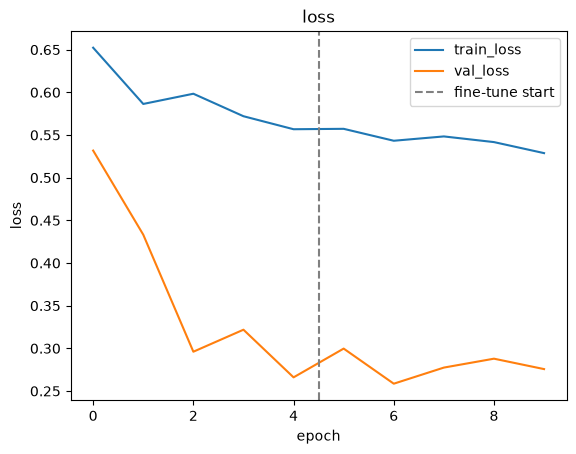

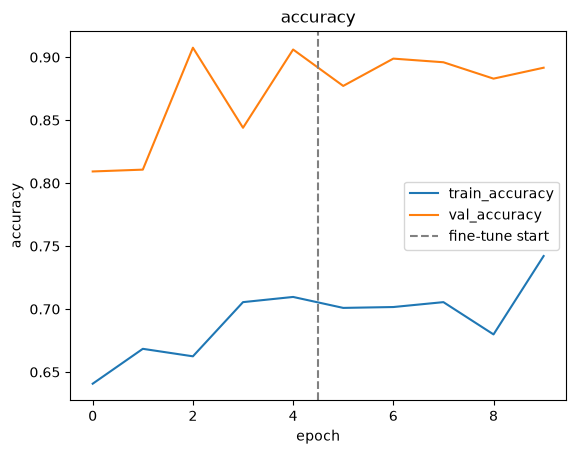

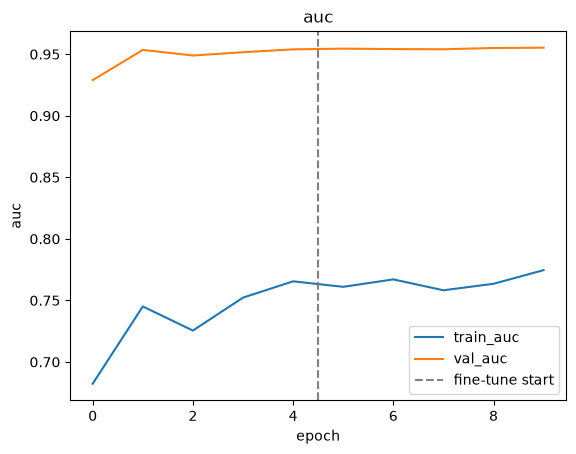

In [12]:
def plot_history(h1, h2, metric):
    vals = h1.history[metric] + h2.history[metric]
    val_vals = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    plt.plot(vals, label=f"train_{metric}")
    plt.plot(val_vals, label=f"val_{metric}")
    plt.axvline(len(h1.history[metric]) - 0.5, color="gray", linestyle="--", label="fine-tune start")
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.title(metric)
    plt.show()


for m in ["loss", "accuracy", "auc"]:
    plot_history(history_head, history_finetune, m)


## 9. Evaluate on the clean test set



25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
              precision    recall  f1-score   support

      NORMAL       0.76      0.89      0.82       268
   PNEUMONIA       0.94      0.86      0.90       526

    accuracy                           0.87       794
   macro avg       0.85      0.87      0.86       794
weighted avg       0.88      0.87      0.87       794



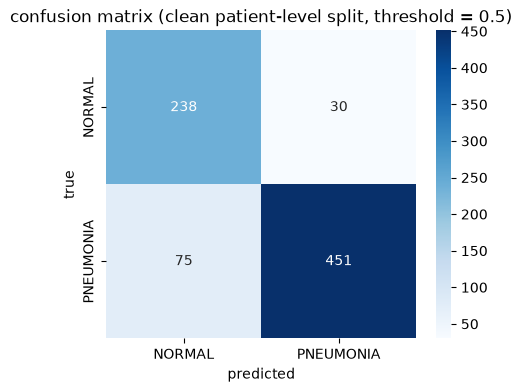

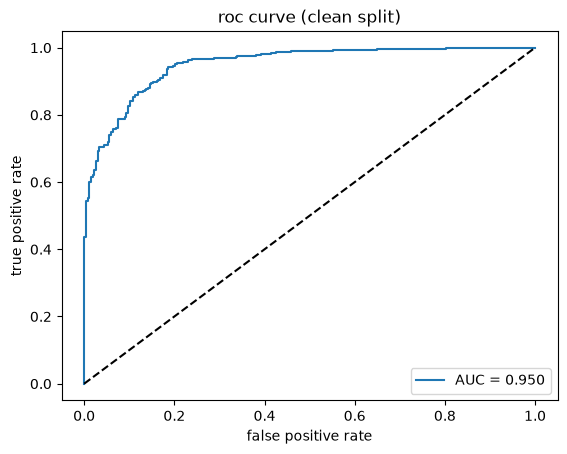

In [13]:
y_true = test_labels_arr.astype(int)
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("confusion matrix (clean patient-level split, threshold = 0.5)")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc curve (clean split)")
plt.legend()
plt.show()


## 10. Threshold sweep on the clean split

In [15]:
print(f"{'threshold':>9} {'acc':>6} {'precision':>10} {'recall':>7} {'f1':>6} {'f2':>6}")
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= threshold).astype(int)
    acc = (y_pred_t == y_true).mean()
    prec = precision_score(y_true, y_pred_t)
    rec = recall_score(y_true, y_pred_t)
    f1 = f1_score(y_true, y_pred_t)
    f2 = fbeta_score(y_true, y_pred_t, beta=2)
    print(f"{threshold:>9.1f} {acc:>6.3f} {prec:>10.3f} {rec:>7.3f} {f1:>6.3f} {f2:>6.3f}")
    print(confusion_matrix(y_true, y_pred_t))
    print()


threshold    acc  precision  recall     f1     f2
      0.3  0.889      0.909   0.926  0.917  0.922
[[219  49]
 [ 39 487]]

      0.4  0.872      0.922   0.880  0.901  0.888
[[229  39]
 [ 63 463]]

      0.5  0.868      0.938   0.857  0.896  0.872
[[238  30]
 [ 75 451]]

      0.6  0.838      0.944   0.802  0.867  0.827
[[243  25]
 [104 422]]

      0.7  0.816      0.957   0.757  0.845  0.790
[[250  18]
 [128 398]]



## 11. Final evaluation at the chosen threshold, save, and log

In [16]:
y_pred_final = (y_prob >= FINAL_THRESHOLD).astype(int)
print(f"Final threshold: {FINAL_THRESHOLD}")
print(classification_report(y_true, y_pred_final, target_names=class_names))
f2_final = fbeta_score(y_true, y_pred_final, beta=2)
print(f"F2 score: {f2_final:.3f}")

model.save(MODEL_OUT)
print(f"model saved to {MODEL_OUT}")


def log_experiment(name, test_acc, test_auc, test_f2, notes=""):
    row = {
        "timestamp": datetime.now().isoformat(),
        "experiment": name,
        "test_accuracy": test_acc,
        "test_auc": test_auc,
        "test_f2": test_f2,
        "notes": notes,
    }
    file_exists = os.path.isfile("experiment_log.csv")
    with open("experiment_log.csv", "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


final_acc = (y_pred_final == y_true).mean()
log_experiment(
    "mobilenetv2_clean_patient_split", final_acc, roc_auc, f2_final,
    notes="patient-level GroupShuffleSplit, zero train/val/test patient overlap",
)


Final threshold: 0.3
              precision    recall  f1-score   support

      NORMAL       0.85      0.82      0.83       268
   PNEUMONIA       0.91      0.93      0.92       526

    accuracy                           0.89       794
   macro avg       0.88      0.87      0.87       794
weighted avg       0.89      0.89      0.89       794

F2 score: 0.922
model saved to pneumonia_mobilenetv2_clean_split.keras


## 12. Grad-CAM on the clean-split model

In [18]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="out_relu"):
    conv_layer = base_model.get_layer(last_conv_layer_name)
    conv_submodel = tf.keras.Model(base_model.input, conv_layer.output)

    with tf.GradientTape() as tape:
        conv_output = conv_submodel(img_array)
        tape.watch(conv_output)
        x = layers.GlobalAveragePooling2D()(conv_output)
        for layer in model.layers[3:]:
            x = layer(x)
        loss = x[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def show_gradcam(image, heatmap, alpha=0.5):
    img_uint8 = image.numpy().astype("uint8") if hasattr(image, "numpy") else image.astype("uint8")
    plt.imshow(img_uint8)
    plt.imshow(heatmap, cmap="jet", alpha=alpha, extent=(0, image.shape[1], image.shape[0], 0))
    plt.axis("off")


def load_raw_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img.numpy()


false_positives = np.where((y_true == 0) & (y_pred_final == 1))[0]
true_negatives = np.where((y_true == 0) & (y_pred_final == 0))[0]
true_positives = np.where((y_true == 1) & (y_pred_final == 1))[0]
print(f"false positives: {len(false_positives)}")


false positives: 49


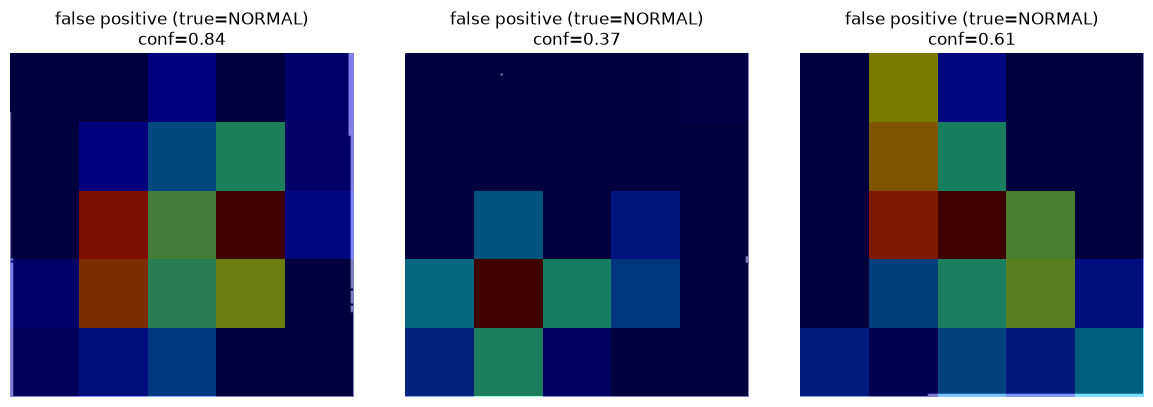

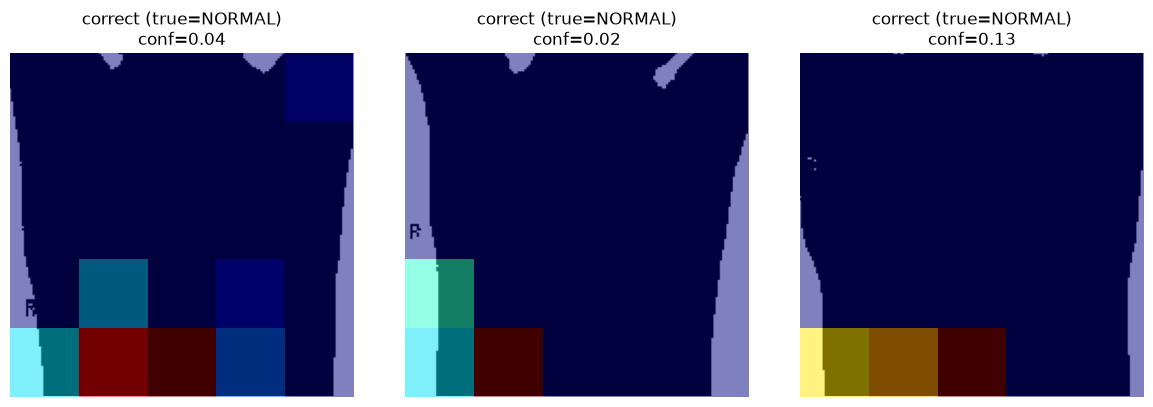

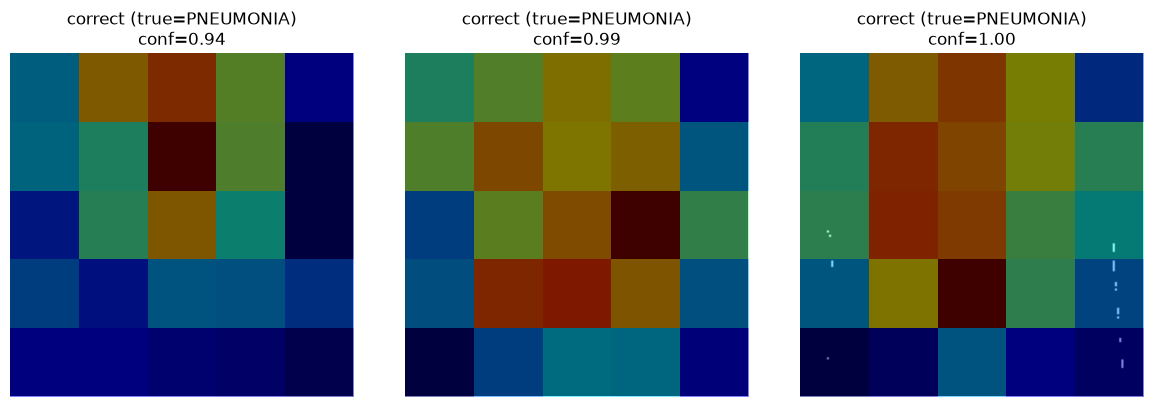

In [19]:
def gradcam_row(indices, title, n=3):
    n = min(n, len(indices))
    if n == 0:
        print(f"no examples for: {title}")
        return
    plt.figure(figsize=(4 * n, 4))
    for i, idx in enumerate(indices[:n]):
        img = load_raw_image(test_paths[idx])
        img_array = preprocess_input(np.expand_dims(img, axis=0))
        heatmap = make_gradcam_heatmap(img_array, model, base_model)
        plt.subplot(1, n, i + 1)
        show_gradcam(img, heatmap)
        plt.title(f"{title}\nconf={y_prob[idx]:.2f}")
    plt.tight_layout()
    plt.show()


gradcam_row(false_positives, "false positive (true=NORMAL)")
gradcam_row(true_negatives, "correct (true=NORMAL)")
gradcam_row(true_positives, "correct (true=PNEUMONIA)")


## 13. Baseline — simple CNN trained from scratch



In [20]:
baseline = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Rescaling(1.0 / 127.5, offset=-1),  # matches MobileNetV2's [-1, 1] preprocessing range
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

# Rebuild plain (non-preprocessed) datasets, since preprocess_input above was tuned for MobileNetV2
def make_raw_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels.astype("float32")))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds_raw_cnn = make_raw_dataset(train_paths, train_labels_arr, training=True)
val_ds_raw_cnn = make_raw_dataset(val_paths, val_labels_arr, training=False)
test_ds_raw_cnn = make_raw_dataset(test_paths, test_labels_arr, training=False)

baseline_history = baseline.fit(
    train_ds_raw_cnn, validation_data=val_ds_raw_cnn, epochs=8,
    class_weight=class_weight,
    callbacks=[EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)],
)

baseline_loss, baseline_acc, baseline_auc = baseline.evaluate(test_ds_raw_cnn)
print(f"baseline CNN  -- test accuracy: {baseline_acc:.3f}  test AUC: {baseline_auc:.3f}")
print(f"MobileNetV2   -- test accuracy: {final_acc:.3f}  test AUC: {roc_auc:.3f}")
print(f"improvement from transfer learning: "
      f"{(final_acc - baseline_acc) * 100:+.1f} pts accuracy, {(roc_auc - baseline_auc):+.3f} AUC")


Epoch 1/8


/opt/anaconda3/envs/pneumonia_project/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.4670 - auc: 0.7147 - loss: 0.6578 - val_accuracy: 0.5751 - val_auc: 0.9302 - val_loss: 0.7549
Epoch 2/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.7922 - auc: 0.8660 - loss: 0.4721 - val_accuracy: 0.7168 - val_auc: 0.9432 - val_loss: 0.5689
Epoch 3/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.8146 - auc: 0.8914 - loss: 0.4183 - val_accuracy: 0.6228 - val_auc: 0.9398 - val_loss: 0.8111
Epoch 4/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.8206 - auc: 0.8988 - loss: 0.3991 - val_accuracy: 0.6777 - val_auc: 0.9438 - val_loss: 0.6482
Epoch 5/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.8158 - auc: 0.9066 - loss: 0.3762 - val_accuracy: 0.7543 - val_auc: 0.9459 - val_loss: 0.5021
Epoch 6/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - accuracy: 0.8279 - auc: 0.9142 - loss: 0.3613 - val_accuracy: 0.7457 - val_auc: 0.9497 - val_loss: 0.4849
Epoch 7/8
137/137 ━━━━━━━━━━━━━━━━━━━━

## 14. Calibration check



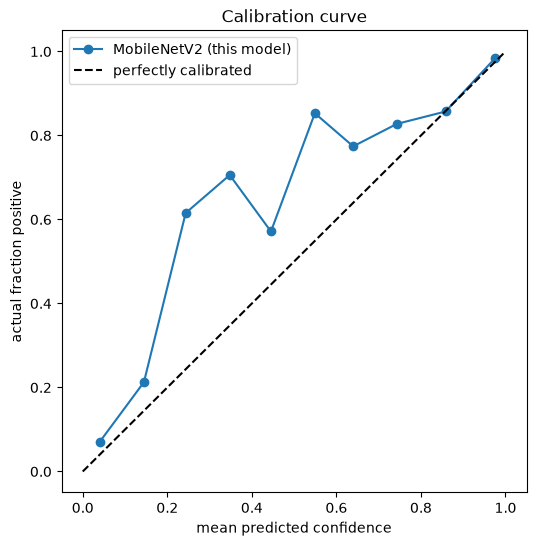

Points above the diagonal = model is under-confident there.
Points below the diagonal = model is over-confident there (riskier failure mode).


In [21]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, "o-", label="MobileNetV2 (this model)")
plt.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
plt.xlabel("mean predicted confidence")
plt.ylabel("actual fraction positive")
plt.title("Calibration curve")
plt.legend()
plt.show()

print("Points above the diagonal = model is under-confident there.")
print("Points below the diagonal = model is over-confident there (riskier failure mode).")


## 15. Stability check — does the result depend on the random seed?



In [22]:
seed_accuracies = []
seed_aucs = []

for trial_seed in [1, 2, 3]:
    tf.random.set_seed(trial_seed)

    trial_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
    trial_base.trainable = False
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    xx = trial_base(inp, training=False)
    xx = layers.GlobalAveragePooling2D()(xx)
    xx = layers.Dense(256, activation="relu")(xx)
    xx = layers.Dropout(0.5)(xx)
    out = layers.Dense(1, activation="sigmoid")(xx)
    trial_model = models.Model(inp, out)
    trial_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                         loss="binary_crossentropy",
                         metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    trial_model.fit(train_ds, validation_data=val_ds, epochs=3,
                     class_weight=class_weight, verbose=0)

    _, trial_acc, trial_auc = trial_model.evaluate(test_ds, verbose=0)
    seed_accuracies.append(trial_acc)
    seed_aucs.append(trial_auc)
    print(f"seed={trial_seed}: acc={trial_acc:.3f} auc={trial_auc:.3f}")

print(f"\nmean accuracy: {np.mean(seed_accuracies):.3f} +/- {np.std(seed_accuracies):.3f}")
print(f"mean AUC:      {np.mean(seed_aucs):.3f} +/- {np.std(seed_aucs):.3f}")


/opt/anaconda3/envs/pneumonia_project/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


seed=1: acc=0.725 auc=0.899
seed=2: acc=0.805 auc=0.923
seed=3: acc=0.843 auc=0.927

mean accuracy: 0.791 +/- 0.049
mean AUC:      0.916 +/- 0.012


In [24]:
seed_accuracies = []
seed_aucs = []

for trial_seed in [1, 2, 3]:
    tf.random.set_seed(trial_seed)

    trial_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
    trial_base.trainable = False
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    xx = trial_base(inp, training=False)
    xx = layers.GlobalAveragePooling2D()(xx)
    xx = layers.Dense(256, activation="relu")(xx)
    xx = layers.Dropout(0.5)(xx)
    out = layers.Dense(1, activation="sigmoid")(xx)
    trial_model = models.Model(inp, out)
    trial_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                         loss="binary_crossentropy",
                         metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    
    trial_model.fit(train_ds, validation_data=val_ds, epochs=5,
                     class_weight=class_weight, verbose=0)


    trial_base.trainable = True
    for layer in trial_base.layers:
        layer.trainable = layer.name.startswith("block_16") or layer.name.startswith("block_15")
    trial_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                         loss="binary_crossentropy",
                         metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    trial_model.fit(train_ds, validation_data=val_ds, epochs=5,
                     class_weight=class_weight, verbose=0)

    _, trial_acc, trial_auc = trial_model.evaluate(test_ds, verbose=0)
    seed_accuracies.append(trial_acc)
    seed_aucs.append(trial_auc)
    print(f"seed={trial_seed}: acc={trial_acc:.3f} auc={trial_auc:.3f}")

print(f"\nmean accuracy: {np.mean(seed_accuracies):.3f} +/- {np.std(seed_accuracies):.3f}")
print(f"mean AUC:      {np.mean(seed_aucs):.3f} +/- {np.std(seed_aucs):.3f}")

seed=1: acc=0.877 auc=0.945
seed=2: acc=0.864 auc=0.940
seed=3: acc=0.879 auc=0.939

mean accuracy: 0.873 +/- 0.007
mean AUC:      0.941 +/- 0.002
